## Рекуррентные сети

Для рекуррентных сетей используем датасет с именами и будем определять из какого языка произошло данное имя. Для этого построим рекуррентную сеть, которая с именами на уровне символов. Для начала скачаем файлы и конвертируем их к удобному формату (можно не особо вникать в этот код).

In [ ]:
# На Windows придется скачать архив по ссылке (~3Mb) и распаковать самостоятельно
! wget -nc https://download.pytorch.org/tutorial/data.zip
! unzip -n ./data.zip

File ‘data.zip’ already there; not retrieving.

Archive:  ./data.zip


In [ ]:
from io import open
import glob

def findFiles(path): return glob.glob(path)

print(findFiles('data/names/*.txt'))

import unicodedata
import string

all_letters = string.ascii_letters + " .,;'"
n_letters = len(all_letters)

# Turn a Unicode string to plain ASCII, thanks to http://stackoverflow.com/a/518232/2809427
def unicodeToAscii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
        and c in all_letters
    )

print(unicodeToAscii('Ślusàrski'))

# Build the category_lines dictionary, a list of names per language
category_lines = {}
all_categories = []

# Read a file and split into lines
def readLines(filename):
    lines = open(filename, encoding='utf-8').read().strip().split('\n')
    return [unicodeToAscii(line) for line in lines]

for filename in findFiles('data/names/*.txt'):
    category = filename.split('/')[-1].split('.')[0]
    all_categories.append(category)
    lines = readLines(filename)
    category_lines[category] = lines

n_categories = len(all_categories)

def categoryFromOutput(output):
    top_n, top_i = output.topk(1)
    category_i = top_i[0][0]
    return all_categories[category_i], category_i

['data/names/Dutch.txt', 'data/names/German.txt', 'data/names/Korean.txt', 'data/names/Greek.txt', 'data/names/Polish.txt', 'data/names/English.txt', 'data/names/Chinese.txt', 'data/names/Scottish.txt', 'data/names/Italian.txt', 'data/names/Spanish.txt', 'data/names/Czech.txt', 'data/names/Portuguese.txt', 'data/names/Japanese.txt', 'data/names/Vietnamese.txt', 'data/names/Irish.txt', 'data/names/Arabic.txt', 'data/names/French.txt', 'data/names/Russian.txt']
Slusarski


Определим несколько удобных функций для конвертации букв и слов в тензоры.

**Задание 1 (1 балл)**: напишите последнюю функцию для конвертации слова в тензор.

In [ ]:
import torch

# Find letter index from all_letters, e.g. "a" = 0
def letterToIndex(letter):
    return all_letters.find(letter)

# Just for demonstration, turn a letter into a <1 x n_letters> Tensor
def letterToTensor(letter):
    tensor = torch.zeros(1, n_letters)
    tensor[0][letterToIndex(letter)] = 1
    return tensor

# Turn a line into a <line_length x 1 x n_letters>,
# or an array of one-hot letter vectors
def lineToTensor(line):
    tensor = torch.zeros(len(line), 1, n_letters)
    for li, letter in enumerate(line):
        tensor[li][0][letterToIndex(letter)] = 1
    return tensor

print(letterToTensor('J'))
print(lineToTensor('Jones').size())

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0.]])
torch.Size([5, 1, 57])


**Задание 2 (3 балла):** Реализуйте однослойную рекуррентную сеть.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
class RNNCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(RNNCell, self).__init__()
        self.hidden_size = hidden_size
        self.features = nn.Sequential(
            nn.Linear(input_size + hidden_size, hidden_size),  # линейный слой: объединённый вход -> скрытое состояние
            nn.Tanh()                                           # нелинейность
        )

    def forward(self, input, hidden):
        # input:  (batch, input_size)
        # hidden: (batch, hidden_size)
        stacked_input = torch.cat((input, hidden), dim=1)       # конкатенация по признакам
        return self.features(stacked_input)                     # новое скрытое состояние

    def initHidden(self):
        return torch.zeros(1, self.hidden_size)                 # начальное скрытое состояние

n_hidden = 128
rnncell = RNNCell(n_letters, n_hidden)

Предсказание будем осуществлять при помощи линейного класссификатора поверх скрытых состояний сети.

In [ ]:
classifier = nn.Sequential(nn.Linear(n_hidden, n_categories), nn.LogSoftmax(dim=1))

Проверим, что все корректно работает: выходы классификаторы должны быть лог-вероятностями.

In [ ]:
input = letterToTensor('A')
hidden = torch.zeros(1, n_hidden)

output = classifier(rnncell(input, hidden))
print(output)
print(torch.exp(output).sum())

tensor([[-2.9938, -2.9521, -2.9029, -2.8473, -2.8860, -2.8527, -2.8388, -2.8635,
         -2.9016, -2.9393, -2.9798, -2.8390, -2.7831, -2.9271, -2.8487, -2.9671,
         -2.9623, -2.7779]], grad_fn=<LogSoftmaxBackward0>)
tensor(1., grad_fn=<SumBackward0>)


In [ ]:
input = lineToTensor('Albert')
hidden = torch.zeros(1, n_hidden)

output = classifier(rnncell(input[0], hidden))
print(output)
print(torch.exp(output).sum())

tensor([[-2.9938, -2.9521, -2.9029, -2.8473, -2.8860, -2.8527, -2.8388, -2.8635,
         -2.9016, -2.9393, -2.9798, -2.8390, -2.7831, -2.9271, -2.8487, -2.9671,
         -2.9623, -2.7779]], grad_fn=<LogSoftmaxBackward0>)
tensor(1., grad_fn=<SumBackward0>)


Для простоты в этот раз будем оптимизировать не по мини-батчам, а по отдельным примерам. Ниже несколько полезных функций для этого.

In [ ]:
import random

def randomChoice(l):
    return l[random.randint(0, len(l) - 1)]

def randomTrainingExample():
    category = randomChoice(all_categories)
    line = randomChoice(category_lines[category])
    category_tensor = torch.tensor([all_categories.index(category)], dtype=torch.long)
    line_tensor = lineToTensor(line)
    return category, line, category_tensor, line_tensor

for i in range(10):
    category, line, category_tensor, line_tensor = randomTrainingExample()
    print('category =', category, '/ line =', line)

category = Korean / line = Li
category = Portuguese / line = Matos
category = English / line = Kirwin
category = Irish / line = Bradach
category = French / line = Charbonneau
category = Italian / line = Adimari
category = German / line = Kaufer
category = Scottish / line = Morrison
category = Polish / line = Kijek
category = Arabic / line = Shamoun


**Задание 3 (1 балл):** Реализуйте вычисление ответа в функции train. Если все сделано правильно, то точность на обучающей выборке должна быть не менее 70%.

100%|██████████| 50000/50000 [01:37<00:00, 514.58it/s]


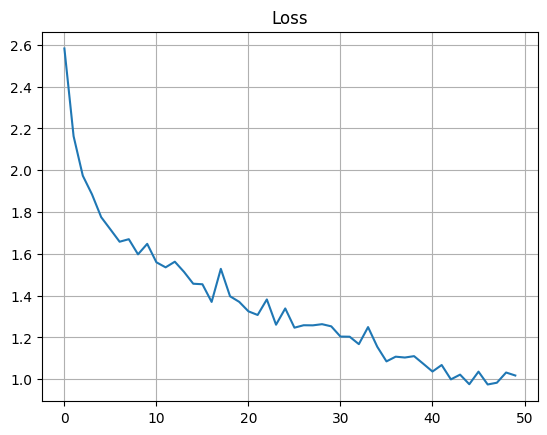

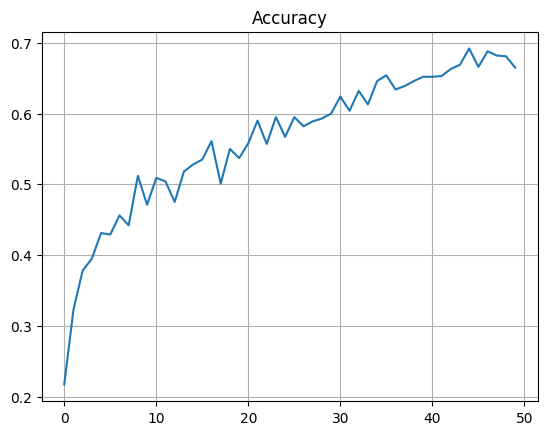

In [ ]:
from tqdm import trange
import matplotlib.pyplot as plt

def train(category, category_tensor, line_tensor, optimizer):
    hidden = rnncell.initHidden()

    rnncell.zero_grad()
    classifier.zero_grad()

    for letter_tensor in line_tensor:
        hidden = rnncell(letter_tensor, hidden)        # подаём очередную букву и предыдущее скрытое состояние

    output = classifier(hidden)                        # классифицируем по последнему скрытому состоянию

    loss = F.nll_loss(output, category_tensor)
    loss.backward()
    optimizer.step()

    acc = (categoryFromOutput(output)[0] == category)

    return loss.item(), acc

n_iters = 50000
plot_every = 1000

current_loss = 0
all_losses = []
current_acc = 0
all_accs = []

n_hidden = 128

rnncell = RNNCell(n_letters, n_hidden)
classifier = nn.Sequential(nn.Linear(n_hidden, n_categories), nn.LogSoftmax(dim=1))
params = list(rnncell.parameters()) + list(classifier.parameters())
opt = torch.optim.RMSprop(params, lr=0.001)
for iter in trange(1, n_iters + 1):
    category, line, category_tensor, line_tensor = randomTrainingExample()
    loss, acc = train(category, category_tensor, line_tensor, opt)
    current_loss += loss
    current_acc += acc

    # Add current loss avg to list of losses
    if iter % plot_every == 0:
        all_losses.append(current_loss / plot_every)
        current_loss = 0
        all_accs.append(current_acc / plot_every)
        current_acc = 0

plt.figure()
plt.title("Loss")
plt.plot(all_losses)
plt.grid()
plt.show()

plt.figure()
plt.title("Accuracy")
plt.plot(all_accs)
plt.grid()
plt.show()

## Затухающие и взрывающиеся градиенты

Эксперименты будем проводить опять на датасете MNIST, но будем работать с полносвязными сетями. В этом разделе мы не будем пытаться подобрать более удачную архитектуру, нам интересно только посмотреть на особенности обучения глубоких сетей.

In [ ]:
import torch
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))
])

train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
val_data   = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

X_train = torch.stack([train_data[i][0] for i in range(len(train_data))])
y_train = torch.tensor([train_data[i][1] for i in range(len(train_data))])

X_val = torch.stack([val_data[i][0] for i in range(len(val_data))])
y_val = torch.tensor([val_data[i][1] for i in range(len(val_data))])

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 509kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.58MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.41MB/s]


torch.Size([60000, 784]) torch.Size([60000])
torch.Size([10000, 784]) torch.Size([10000])


In [ ]:
import numpy as np
def test(model):
    loss_log, acc_log = [], []
    model.eval()
    for x_batch, y_batch in iterate_minibatches(X_val, y_val, batchsize=32, shuffle=True):
        data = torch.from_numpy(x_batch.astype(np.float32))
        target = torch.from_numpy(y_batch.astype(np.int64))

        output = model(data)
        loss = F.nll_loss(output, target)

        pred = torch.max(output, 1)[1].numpy()
        acc = np.mean(pred == y_batch)
        acc_log.append(acc)

        loss = loss.item()
        loss_log.append(loss)
    return loss_log, acc_log

def plot_history(train_history, val_history, title='loss'):
    plt.figure()
    plt.title('{}'.format(title))
    plt.plot(train_history, label='train', zorder=1)

    points = np.array(val_history)

    plt.scatter(points[:, 0], points[:, 1], marker='+', s=180, c='orange', label='val', zorder=2)
    plt.xlabel('train steps')

    plt.legend(loc='best')
    plt.grid()

    plt.show()

Для экспериментов нам понадобится сеть, в которой можно легко менять количество слоев. Также эта сеть должна сохранять градиенты на всех слоях, чтобы потом мы могли посмотреть на их величины.

In [ ]:
class DeepDenseNet(nn.Module):
    def __init__(self, n_layers, hidden_size, activation):
        super().__init__()
        self.activation = activation

        l0 = nn.Linear(X_train.shape[1], hidden_size)
        self.weights = [l0.weight]
        self.layers = [l0]

        for i in range(n_layers):
            self.layers.append(self.activation)
            linear = nn.Linear(hidden_size, hidden_size)
            self.layers.append(linear)
            self.weights.append(linear.weight)

        self.seq = nn.Sequential(*self.layers)

        for l in self.weights:
            l.retain_grad()

    def forward(self, x):
        out = self.seq(x)
        return F.log_softmax(out, dim=-1)

Модифицируем наши функции обучения, чтобы они также рисовали графики изменения градиентов.

In [ ]:
import scipy.sparse.linalg

def iterate_minibatches(inputs, targets, batchsize, shuffle=False):
    assert len(inputs) == len(targets)
    if shuffle:
        indices = np.random.permutation(len(inputs))
    for start_idx in trange(0, len(inputs) - batchsize + 1, batchsize):
        if shuffle:
            excerpt = indices[start_idx:start_idx + batchsize]
        else:
            excerpt = slice(start_idx, start_idx + batchsize)
        yield inputs[excerpt], targets[excerpt]

def train_epoch_grad(model, optimizer, batchsize=32):
    loss_log, acc_log = [], []
    grads = [[] for l in model.weights]
    model.train()
    for x_batch, y_batch in iterate_minibatches(X_train, y_train, batchsize=batchsize, shuffle=True):
        # data preparation
        data = torch.from_numpy(x_batch.astype(np.float32))
        target = torch.from_numpy(y_batch.astype(np.int64))

        optimizer.zero_grad()
        output = model(data)

        pred = torch.max(output, 1)[1].cpu().numpy()
        acc = np.mean(pred == y_batch)
        acc_log.append(acc)

        loss = F.nll_loss(output, target)
        loss.backward()
        optimizer.step()
        loss = loss.item()
        loss_log.append(loss)

        for g, l in zip(grads, model.weights):
            g.append(np.linalg.norm(l.grad.cpu().numpy()))
    return loss_log, acc_log, grads


def train_grad(model, opt, n_epochs):
    train_log, train_acc_log = [], []
    val_log, val_acc_log = [], []
    grads_log = None

    batchsize = 32

    for epoch in range(n_epochs):
        print("Epoch {} of {}".format(epoch, n_epochs))
        train_loss, train_acc, grads = train_epoch_grad(model, opt, batchsize=batchsize)
        if grads_log is None:
            grads_log = grads
        else:
            for a, b in zip(grads_log, grads):
                a.extend(b)

        val_loss, val_acc = test(model)

        train_log.extend(train_loss)
        train_acc_log.extend(train_acc)

        steps = len(X_train) / batchsize
        val_log.append((steps * (epoch + 1), np.mean(val_loss)))
        val_acc_log.append((steps * (epoch + 1), np.mean(val_acc)))

        # display all metrics
        clear_output()
        plot_history(train_log, val_log)
        plot_history(train_acc_log, val_acc_log, title='accuracy')

        plt.figure()
        all_vals = []
        for i, g in enumerate(grads_log):
            w = np.ones(100)
            w /= w.sum()
            vals = np.convolve(w, g, mode='valid')
            plt.semilogy(vals, label=str(i+1), color=plt.cm.coolwarm((i / len(grads_log))))
            all_vals.extend(vals)
        plt.legend(loc='best')
        plt.grid()
        plt.show()

**Задание 4 (1 балл):**
* Обучите сети глубины 10 и больше с сигмоидой в качестве активации. Исследуйте, как глубина влияет на качество обучения и поведение градиентов на далеких от выхода слоях.


--- Training depth 10 ---
Epoch 0 of 10
  loss: 2.3064
Epoch 1 of 10
  loss: 2.3016
Epoch 2 of 10
  loss: 2.3014
Epoch 3 of 10
  loss: 2.3014
Epoch 4 of 10
  loss: 2.3014
Epoch 5 of 10
  loss: 2.3013
Epoch 6 of 10
  loss: 2.3014
Epoch 7 of 10
  loss: 2.3014
Epoch 8 of 10
  loss: 2.3014
Epoch 9 of 10
  loss: 2.3014

--- Training depth 15 ---
Epoch 0 of 10
  loss: 2.3069
Epoch 1 of 10
  loss: 2.3014
Epoch 2 of 10
  loss: 2.3014
Epoch 3 of 10
  loss: 2.3014
Epoch 4 of 10
  loss: 2.3014
Epoch 5 of 10
  loss: 2.3014
Epoch 6 of 10
  loss: 2.3013
Epoch 7 of 10
  loss: 2.3013
Epoch 8 of 10
  loss: 2.3014
Epoch 9 of 10
  loss: 2.3014

--- Training depth 20 ---
Epoch 0 of 10
  loss: 2.3064
Epoch 1 of 10
  loss: 2.3016
Epoch 2 of 10
  loss: 2.3014
Epoch 3 of 10
  loss: 2.3014
Epoch 4 of 10
  loss: 2.3014
Epoch 5 of 10
  loss: 2.3013
Epoch 6 of 10
  loss: 2.3014
Epoch 7 of 10
  loss: 2.3014
Epoch 8 of 10
  loss: 2.3013
Epoch 9 of 10
  loss: 2.3014


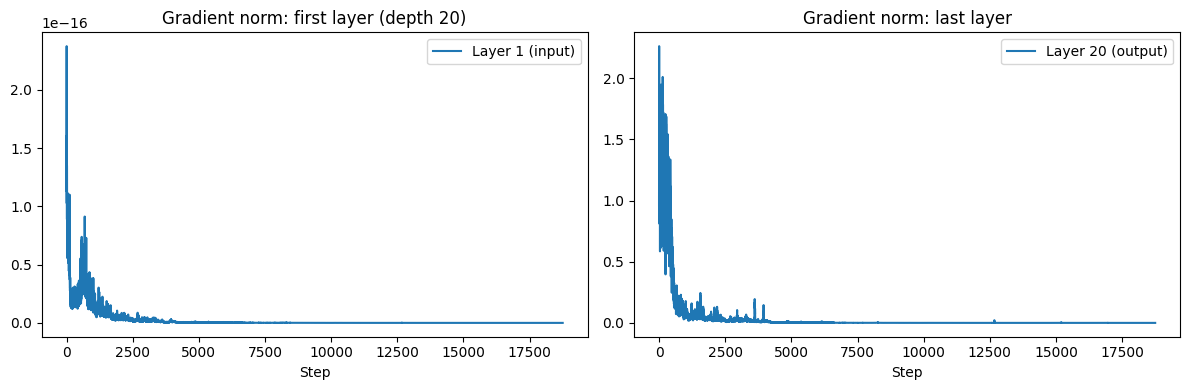

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

# ---------- Загрузка и подготовка данных ----------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))  # flatten 28x28 -> 784
])

train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
val_data   = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Преобразуем в numpy-массивы, которые ожидает iterate_minibatches
X_train = torch.stack([train_data[i][0] for i in range(len(train_data))]).numpy()
y_train = torch.tensor([train_data[i][1] for i in range(len(train_data))]).numpy()
X_val   = torch.stack([val_data[i][0] for i in range(len(val_data))]).numpy()
y_val   = torch.tensor([val_data[i][1] for i in range(len(val_data))]).numpy()

# ---------- Генератор батчей ----------
def iterate_minibatches(X, y, batchsize=32, shuffle=True):
    indices = np.arange(len(X))
    if shuffle:
        np.random.shuffle(indices)
    for start_idx in range(0, len(X) - batchsize + 1, batchsize):
        excerpt = indices[start_idx:start_idx + batchsize]
        yield X[excerpt], y[excerpt]

# ---------- Класс глубокой сети с сигмоидой ----------
class DeepDenseNet(nn.Module):
    def __init__(self, input_size=784, hidden_size=256, output_size=10, n_layers=5):
        super().__init__()
        layers = []
        in_size = input_size
        for _ in range(n_layers - 1):  # скрытые слои с сигмоидой
            layers.append(nn.Linear(in_size, hidden_size))
            layers.append(nn.Sigmoid())
            in_size = hidden_size
        # выходной слой
        layers.append(nn.Linear(in_size, output_size))
        layers.append(nn.LogSoftmax(dim=1))
        self.net = nn.Sequential(*layers)

        # список весов всех Linear-слоёв (нужен для train_grad)
        self.weights = [layer.weight for layer in self.net if isinstance(layer, nn.Linear)]

    def forward(self, x):
        return self.net(x)

# ---------- Обучение и логирование градиентов ----------
def train_grad(model, optimizer, epochs=10, batchsize=32):
    """ train_grad, как в задании: выводит эпохи, потери и логирует градиенты """
    loss_history = []
    grad_norms = {i: [] for i in range(len(model.weights))}
    for epoch in range(epochs):
        print(f"Epoch {epoch} of {epochs}")
        model.train()
        total_loss = 0
        for x_batch, y_batch in iterate_minibatches(X_train, y_train, batchsize=batchsize, shuffle=True):
            data = torch.from_numpy(x_batch.astype(np.float32))
            target = torch.from_numpy(y_batch.astype(np.int64))

            optimizer.zero_grad()
            output = model(data)
            loss = F.nll_loss(output, target)
            loss.backward()

            # сохраняем нормы градиентов весов
            for i, w in enumerate(model.weights):
                if w.grad is not None:
                    grad_norms[i].append(w.grad.norm().item())

            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / (len(X_train) // batchsize)
        loss_history.append(avg_loss)
        print(f"  loss: {avg_loss:.4f}")
    return loss_history, grad_norms

# ---------- Эксперимент: сети глубины 10, 15, 20 ----------
depths = [10, 15, 20]
histories = {}
for depth in depths:
    print(f"\n--- Training depth {depth} ---")
    model = DeepDenseNet(n_layers=depth)
    loss_hist, grad_norms = train_grad(model, torch.optim.Adam(model.parameters()), epochs=10)
    histories[depth] = (loss_hist, grad_norms)

# Визуализация градиентов для первого и последнего слоя одной из сетей (опционально)
depth = 20
loss_hist, grad_norms = histories[depth]
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(grad_norms[0], label='Layer 1 (input)')
plt.title(f'Gradient norm: first layer (depth {depth})')
plt.xlabel('Step')
plt.legend()
plt.subplot(1,2,2)
plt.plot(grad_norms[len(model.weights)-1], label=f'Layer {len(model.weights)} (output)')
plt.title('Gradient norm: last layer')
plt.xlabel('Step')
plt.legend()
plt.tight_layout()
plt.show()

* Теперь замените активацию на ReLU и посмотрите, что получится.

In [ ]:
# Класс глубокой сети с ReLU (вместо сигмоиды)
class DeepDenseNetReLU(nn.Module):
    def __init__(self, input_size=784, hidden_size=256, output_size=10, n_layers=5):
        super().__init__()
        layers = []
        in_size = input_size
        for _ in range(n_layers - 1):          # скрытые слои с ReLU
            layers.append(nn.Linear(in_size, hidden_size))
            layers.append(nn.ReLU())            # <--- замена сигмоиды на ReLU
            in_size = hidden_size
        layers.append(nn.Linear(in_size, output_size))
        layers.append(nn.LogSoftmax(dim=1))
        self.net = nn.Sequential(*layers)

        # список весов для train_grad
        self.weights = [layer.weight for layer in self.net if isinstance(layer, nn.Linear)]

    def forward(self, x):
        return self.net(x)

# Обучение сетей с ReLU разной глубины
model_relu_10 = DeepDenseNetReLU(n_layers=10)
train_grad(model_relu_10, torch.optim.Adam(model_relu_10.parameters()), 10)

model_relu_15 = DeepDenseNetReLU(n_layers=15)
train_grad(model_relu_15, torch.optim.Adam(model_relu_15.parameters()), 10)

model_relu_20 = DeepDenseNetReLU(n_layers=20)
train_grad(model_relu_20, torch.optim.Adam(model_relu_20.parameters()), 10)

Epoch 0 of 10
  loss: 0.5491
Epoch 1 of 10
  loss: 0.2047
Epoch 2 of 10
  loss: 0.1588
Epoch 3 of 10
  loss: 0.1284
Epoch 4 of 10
  loss: 0.1080
Epoch 5 of 10
  loss: 0.0875
Epoch 6 of 10
  loss: 0.0861
Epoch 7 of 10
  loss: 0.0730
Epoch 8 of 10
  loss: 0.0635
Epoch 9 of 10
  loss: 0.0634
Epoch 0 of 10
  loss: 1.0829
Epoch 1 of 10
  loss: 0.6089
Epoch 2 of 10
  loss: 0.6507
Epoch 3 of 10
  loss: 0.6139
Epoch 4 of 10
  loss: 0.6498
Epoch 5 of 10
  loss: 0.8210
Epoch 6 of 10
  loss: 0.7262
Epoch 7 of 10
  loss: 0.6309
Epoch 8 of 10
  loss: 0.6198
Epoch 9 of 10
  loss: 0.7020
Epoch 0 of 10
  loss: 2.1488
Epoch 1 of 10
  loss: 0.9994
Epoch 2 of 10
  loss: 0.7713
Epoch 3 of 10
  loss: 0.6393
Epoch 4 of 10
  loss: 0.8248
Epoch 5 of 10
  loss: 0.5676
Epoch 6 of 10
  loss: 0.5307
Epoch 7 of 10
  loss: 0.7031
Epoch 8 of 10
  loss: 0.5165
Epoch 9 of 10
  loss: 0.4149


([2.148838116168976,
  0.9994344373544057,
  0.7712815402507782,
  0.639282247710228,
  0.8247841727733612,
  0.5675755886077881,
  0.5306867817282677,
  0.7030554458618165,
  0.5164508025566736,
  0.41492598998943964],
 {0: [6.146862574496481e-08,
   4.840515543946822e-08,
   5.5449401514806596e-08,
   4.8262073448768206e-08,
   5.0106855553622154e-08,
   4.101977069126406e-08,
   7.695115300521138e-08,
   1.2149462236266118e-07,
   8.111526028642402e-08,
   7.509757438128872e-08,
   8.184461819382705e-08,
   9.772188036549778e-08,
   1.0432858488229613e-07,
   1.9032300713206496e-07,
   4.4135157395430724e-07,
   7.031723043837701e-07,
   2.82879682345083e-07,
   1.6457261153846048e-07,
   9.518867472024795e-08,
   6.85154333268656e-08,
   4.7315619866594716e-08,
   3.575345175477196e-08,
   2.6843087752581596e-08,
   1.7727010970247647e-08,
   1.828823670280144e-08,
   1.7409011121571893e-08,
   1.5607765746494806e-08,
   1.6242196920757124e-08,
   1.4494174749302147e-08,
   1.75185

Теперь попробуем добавить в сеть skip-connections (по примеру ResNet) вместо замены сигмоиды на relu и посмотрим, что получится. Запихнуть все слои в nn.Sequential и просто их применить теперь не получится - вместо этого мы их применим вручную. Но положить их в отдельный модуль nn.Sequential все равно нужно, иначе torch не сможет их найти и оптимизировать.

**Задание 5 (4 балла):** допишите недостающую часть кода ниже.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DeepDenseResNet(nn.Module):
    def __init__(self, n_layers, hidden_size, activation):
        super().__init__()
        self.activation = activation

        l0 = nn.Linear(X_train.shape[1], hidden_size)
        self.weights = [l0.weight]
        self.layers = [l0]

        for i in range(1, n_layers - 1):
            l = nn.Linear(hidden_size, hidden_size)
            self.layers.append(l)
            self.weights.append(l.weight)

        l = nn.Linear(hidden_size, 10)
        self.layers.append(l)
        self.weights.append(l.weight)

        self.seq = nn.Sequential(*self.layers)

        for l in self.weights:
            l.retain_grad()

    def forward(self, x):
        # Первый слой без skip-connection
        x = self.layers[0](x)
        x = self.activation(x)

        # Скрытые слои с residual connections
        for i in range(1, len(self.layers) - 1):
            identity = x                          # сохраняем вход для skip-connection
            x = self.layers[i](x)                 # линейное преобразование
            x = self.activation(x)                # активация
            x = x + identity                      # skip-connection (сложение с входом)

        # Выходной слой (без активации, log_softmax применяется после)
        x = self.layers[-1](x)

        return F.log_softmax(x, dim=-1)

Убедимся, что такая сеть отлично учится даже на большом числе слоев.

In [ ]:
model = DeepDenseResNet(n_layers=20, hidden_size=10, activation=nn.Sigmoid())
opt = torch.optim.RMSprop(model.parameters(), lr=0.001)

train_grad(model, opt, 10)

Epoch 0 of 10
  loss: 0.7522
Epoch 1 of 10
  loss: 0.3455
Epoch 2 of 10
  loss: 0.2906
Epoch 3 of 10
  loss: 0.2615
Epoch 4 of 10
  loss: 0.2426
Epoch 5 of 10
  loss: 0.2298
Epoch 6 of 10
  loss: 0.2189
Epoch 7 of 10
  loss: 0.2091
Epoch 8 of 10
  loss: 0.1999
Epoch 9 of 10
  loss: 0.1942


([0.7521660683075587,
  0.34545063682198524,
  0.29061976404190065,
  0.26148009767383334,
  0.24260382250249385,
  0.2297643868803978,
  0.21886381168017785,
  0.2090760024274389,
  0.19985466036597888,
  0.19423818441430726],
 {0: [0.7565479278564453,
   0.5315088033676147,
   0.4031980335712433,
   0.340459406375885,
   0.23337817192077637,
   0.20986314117908478,
   0.24950259923934937,
   0.2883390486240387,
   0.15504752099514008,
   0.18990808725357056,
   0.14015929400920868,
   0.13221488893032074,
   0.18679502606391907,
   0.2731586992740631,
   0.18517445027828217,
   0.15028069913387299,
   0.16770340502262115,
   0.16732557117938995,
   0.17133015394210815,
   0.16394272446632385,
   0.15723064541816711,
   0.18159742653369904,
   0.21710240840911865,
   0.14814291894435883,
   0.3565785884857178,
   0.3019016981124878,
   0.18375863134860992,
   0.1715373992919922,
   0.197758287191391,
   0.22692230343818665,
   0.19695165753364563,
   0.18404518067836761,
   0.19170188